# Training and Deploying ML Models using JAX on SageMaker (SDK v3)


---

This notebook's CI test result for us-west-2 is as follows. CI test results in other regions can be found at the end of the notebook. 

![This us-west-2 badge failed to load. Check your device's internet connectivity, otherwise the service is currently unavailable](https://prod.us-west-2.tcx-beacon.docs.aws.dev/sagemaker-nb/us-west-2/build_and_train_models|sm-jax_bring_your_own|sm-jax_bring_your_own.ipynb)

---

Amazon SageMaker provides you the flexibility to train models using our pre-built machine learning containers or your own bespoke container. We'll refer to these strategies as Bring-Your-Own-Script **(BYOS)** and Bring-Your-Own-Container **(BYOC)** in this tutorial. 

### Bring Your Own JAX Script

In this notebook, we'll show how to extend our optimized TensorFlow containers to train machine learning models using the increasingly popular [JAX library](https://github.com/google/jax). We'll train a fashion MNIST classification model using vanilla JAX, another using `jax.experimental.stax`, and a final model using the [higher level Trax library](https://github.com/google/trax).

For all three patterns, we'll show how the JAX models can be serialized as standard TensorFlow [SavedModel format](https://www.tensorflow.org/guide/saved_model). This enables us to seamlessly deploy the models using the managed and optimized SageMaker TensorFlow inference containers.

### Bring Your Own JAX Container

We've included a dockerfile in this repo directory to show how you can build your own bespoke JAX container with support for GPUs on SageMaker. Unfortunately, the NVIDIA/CUDA Dockerhub containers have a [deletion policy](https://gitlab.com/nvidia/container-images/cuda/blob/master/doc/support-policy.md), so we're unable to assert that the container can be built through time. Nonetheless, you can trivially adapt a newer version of the container if your workload requires a custom container. For more information on running BYOC on SageMaker see the [documentation](https://docs.aws.amazon.com/sagemaker/latest/dg/adapt-training-container.html).

### SDK v3 note

This notebook uses the **SageMaker Python SDK v3** APIs. The V2 framework estimator `sagemaker.tensorflow.TensorFlow` is replaced by `sagemaker.train.ModelTrainer` combined with `sagemaker.core.image_uris.retrieve` to select the managed TensorFlow container. Deployment uses the `sagemaker-core` resource classes (`Model`, `EndpointConfig`, `Endpoint`) instead of the V2 `estimator.deploy()` / `Predictor` pattern. The container-side training scripts in `training_scripts/` and their `requirements.txt` (which installs JAX) are unchanged.

In [1]:
# [papermill-run] pip install disabled; packages preinstalled in exec env
print('pip install skipped for papermill run')


pip install skipped for papermill run


In [2]:
import json
from time import gmtime, strftime

from sagemaker.train import ModelTrainer
from sagemaker.train.configs import SourceCode, Compute
from sagemaker.core import image_uris
from sagemaker.core.shapes import StoppingCondition
from sagemaker.core.helper.session_helper import Session, get_execution_role

import os  # [papermill-run]
os.environ["AWS_DEFAULT_REGION"] = "us-west-1"  # [papermill-run] region for boto session
import boto3  # [papermill-run]
sess = Session(boto_session=boto3.Session(region_name="us-west-1"))  # [papermill-run] explicit region
role = "arn:aws:iam::729646638167:role/SageMakerRole"  # [papermill-run] explicit role
region = "us-west-1"  # [papermill-run] explicit region
print(f"Region: {region}")

[07/13/26 12:01:31] INFO     Found credentials in shared credentials file: ~/.aws/credentials   ]8;id=3582373;file:///Users/lucasjia/pysdk/pysdk-workspace/.v3test-venv/lib/python3.12/site-packages/botocore/credentials.py\credentials.py]8;;\:]8;id=3582374;file:///Users/lucasjia/pysdk/pysdk-workspace/.v3test-venv/lib/python3.12/site-packages/botocore/credentials.py#1392\1392]8;;\

sagemaker.config INFO - Not applying SDK defaults from location: /Library/Application Support/sagemaker/config.yaml


sagemaker.config INFO - Not applying SDK defaults from location: /Users/lucasjia/Library/Application Support/sagemaker/config.yaml


                    INFO     Found credentials in shared credentials file: ~/.aws/credentials   ]8;id=3582379;file:///Users/lucasjia/pysdk/pysdk-workspace/.v3test-venv/lib/python3.12/site-packages/botocore/credentials.py\credentials.py]8;;\:]8;id=3582380;file:///Users/lucasjia/pysdk/pysdk-workspace/.v3test-venv/lib/python3.12/site-packages/botocore/credentials.py#1392\1392]8;;\

Region: us-west-1


## Installing JAX in SageMaker TensorFlow Containers

When using BYOS with managed SageMaker containers, you can trivially install extra dependencies by providing a `requirements.txt` within the `source_dir` that contains your training scripts. At runtime these dependencies will be installed prior to executing the training script, so we can utilize our optimized TensorFlow GPU container to utilize JAX with CUDA support.

To be specific, any container that has the [sagemaker-training-toolkit](https://github.com/aws/sagemaker-training-toolkit) supports installing additional dependencies from `requirements.txt`. In the SDK v3 `ModelTrainer`, the `requirements.txt` path is passed via the `requirements` field of `SourceCode`.


## Serializing models as SavedModel format
In the upcoming training jobs we'll be training a vanilla JAX model, a Stax model, and a Trax model on the [fashion MNIST dataset](https://github.com/zalandoresearch/fashion-mnist).
The full details of the model can be seen in the `training_scripts/` directory, but it is worth calling out the methods for serialization.

The JAX/Stax models utilize the new jax2tf converter: https://github.com/google/jax/tree/master/jax/experimental/jax2tf

```python
def save_model_tf(prediction_function, params_to_save):
    tf_fun = jax2tf.convert(prediction_function, enable_xla=False)
    param_vars = tf.nest.map_structure(lambda param: tf.Variable(param), params_to_save)

    tf_graph = tf.function(
        lambda inputs: tf_fun(param_vars, inputs),
        autograph=False,
        jit_compile=False,
    )

```


The Trax model utilizes the new trax2keras functionality: https://github.com/google/trax/blob/master/trax/trax2keras.py

```python
def save_model_tf(model_to_save):
    """
    Serialize a TensorFlow graph from trained Trax Model
    :param model_to_save: Trax Model
    """
    keras_layer = trax.AsKeras(model_to_save, batch_size=1)
    inputs = tf.keras.Input(shape=(28, 28, 1))
    hidden = keras_layer(inputs)

    keras_model = tf.keras.Model(inputs=inputs, outputs=hidden)
    keras_model.save("/opt/ml/model/1", save_format="tf")
```

## Retrieve the managed TensorFlow training and inference images

In V2 the `TensorFlow` estimator resolved the container image automatically from `framework_version` / `py_version`. In V3 we retrieve the image URI explicitly with `image_uris.retrieve` and pass it to `ModelTrainer`. We retrieve both the training image (used to run the JAX scripts) and the inference image (managed TF Serving, used to host the SavedModel).

In [3]:
TF_FRAMEWORK_VERSION = "2.10"
TF_PY_VERSION = "py39"
TRAIN_INSTANCE_TYPE = "ml.g4dn.xlarge"  # [papermill-run] us-west-1 has no p3
INFERENCE_INSTANCE_TYPE = "ml.m4.xlarge"

training_image = image_uris.retrieve(
    framework="tensorflow",
    region=region,
    version=TF_FRAMEWORK_VERSION,
    py_version=TF_PY_VERSION,
    instance_type=TRAIN_INSTANCE_TYPE,
    image_scope="training",
)

inference_image = image_uris.retrieve(
    framework="tensorflow",
    region=region,
    version=TF_FRAMEWORK_VERSION,
    py_version=TF_PY_VERSION,
    instance_type=INFERENCE_INSTANCE_TYPE,
    image_scope="inference",
)

print("Training image:", training_image)
print("Inference image:", inference_image)

                    INFO     Ignoring unnecessary Python version: py39.                           ]8;id=3582387;file:///Users/lucasjia/pysdk/pysdk-workspace/sagemaker-python-sdk-lucas/sagemaker-core/src/sagemaker/core/image_uris.py\image_uris.py]8;;\:]8;id=3582388;file:///Users/lucasjia/pysdk/pysdk-workspace/sagemaker-python-sdk-lucas/sagemaker-core/src/sagemaker/core/image_uris.py#608\608]8;;\

Training image: 763104351884.dkr.ecr.us-west-1.amazonaws.com/tensorflow-training:2.10-gpu-py39
Inference image: 763104351884.dkr.ecr.us-west-1.amazonaws.com/tensorflow-inference:2.10-cpu


## Train using Vanilla JAX

Note: Our `source_dir` directory contains a `requirements.txt` that will install JAX with CUDA support. We pass it via `SourceCode(requirements=...)`.

In [4]:
vanilla_jax_trainer = ModelTrainer(
    training_image=training_image,
    role=role,
    base_job_name="jax",
    source_code=SourceCode(
        source_dir="/Users/lucasjia/pysdk/pysdk-workspace/amazon-sagemaker-examples-lucas/      build_and_train_models/sm-jax_bring_your_own/training_scripts",  # [papermill-run] absolute path
        entry_script="train_jax.py",
        requirements="requirements.txt",
    ),
    compute=Compute(
        instance_type=TRAIN_INSTANCE_TYPE,
        instance_count=1,
    ),
    stopping_condition=StoppingCondition(max_runtime_in_seconds=3600),
    hyperparameters={"num_epochs": 3},
    sagemaker_session=sess,
)
vanilla_jax_trainer.train(logs=False)

[07/13/26 12:01:32] INFO     Role 'arn:aws:iam::729646638167:role/SageMakerRole' validated ]8;id=3582395;file:///Users/lucasjia/pysdk/pysdk-workspace/sagemaker-python-sdk-lucas/sagemaker-core/src/sagemaker/core/helper/iam_role_resolver.py\iam_role_resolver.py]8;;\:]8;id=3582396;file:///Users/lucasjia/pysdk/pysdk-workspace/sagemaker-python-sdk-lucas/sagemaker-core/src/sagemaker/core/helper/iam_role_resolver.py#598\598]8;;\
                             for training. Using it.                                                               

                    INFO     OutputDataConfig not provided. Using default:                          ]8;id=3582403;file:///Users/lucasjia/pysdk/pysdk-workspace/sagemaker-python-sdk-lucas/sagemaker-train/src/sagemaker/train/defaults.py\defaults.py]8;;\:]8;id=3582404;file:///Users/lucasjia/pysdk/pysdk-workspace/sagemaker-python-sdk-lucas/sagemaker-train/src/sagemaker/train/defaults.py#192\192]8;;\
                             s3_output_path='s3://sagemaker-us-west-1-729646638167/jax'                            
                             kms_key_id=None compression_type='GZIP'                                               

                    INFO     Training image URI:                                               ]8;id=3582411;file:///Users/lucasjia/pysdk/pysdk-workspace/sagemaker-python-sdk-lucas/sagemaker-train/src/sagemaker/train/model_trainer.py\model_trainer.py]8;;\:]8;id=3582412;file:///Users/lucasjia/pysdk/pysdk-workspace/sagemaker-python-sdk-lucas/sagemaker-train/src/sagemaker/train/model_trainer.py#558\558]8;;\
                             763104351884.dkr.ecr.us-west-1.amazonaws.com/tensorflow-training:                     
                             2.10-gpu-py39                                                                         

                    INFO     SageMaker Python SDK will collect telemetry to help us better ]8;id=3582419;file:///Users/lucasjia/pysdk/pysdk-workspace/sagemaker-python-sdk-lucas/sagemaker-core/src/sagemaker/core/telemetry/telemetry_logging.py\telemetry_logging.py]8;;\:]8;id=3582420;file:///Users/lucasjia/pysdk/pysdk-workspace/sagemaker-python-sdk-lucas/sagemaker-core/src/sagemaker/core/telemetry/telemetry_logging.py#287\287]8;;\
                             understand our user's needs, diagnose issues, and deliver                             
                             additional features.                                                                  
                             To opt out of telemetry, please disable via TelemetryOptOut                           
                             parameter in SDK defaults config. For more information, refer                         
                             to                                                                                    
                             https://sagemaker.readthedocs.io/en/stable/overview.html#conf                         
                             iguring-and-using-defaults-with-the-sagemaker-python-sdk.                             

sagemaker.config INFO - Not applying SDK defaults from location: /Library/Application Support/sagemaker/config.yaml


...

                    WARNING  No region provided. Using default region.                                 ]8;id=3582435;file:///Users/lucasjia/pysdk/pysdk-workspace/sagemaker-python-sdk-lucas/sagemaker-core/src/sagemaker/core/utils/utils.py\utils.py]8;;\:]8;id=3582436;file:///Users/lucasjia/pysdk/pysdk-workspace/sagemaker-python-sdk-lucas/sagemaker-core/src/sagemaker/core/utils/utils.py#361\361]8;;\

                    INFO     Runs on sagemaker prod, region:us-west-1                                  ]8;id=3582442;file:///Users/lucasjia/pysdk/pysdk-workspace/sagemaker-python-sdk-lucas/sagemaker-core/src/sagemaker/core/utils/utils.py\utils.py]8;;\:]8;id=3582443;file:///Users/lucasjia/pysdk/pysdk-workspace/sagemaker-python-sdk-lucas/sagemaker-core/src/sagemaker/core/utils/utils.py#375\375]8;;\

                    INFO     Found credentials in shared credentials file: ~/.aws/credentials   ]8;id=3582448;file:///Users/lucasjia/pysdk/pysdk-workspace/.v3test-venv/lib/python3.12/site-packages/botocore/credentials.py\credentials.py]8;;\:]8;id=3582449;file:///Users/lucasjia/pysdk/pysdk-workspace/.v3test-venv/lib/python3.12/site-packages/botocore/credentials.py#1392\1392]8;;\

Output()

[07/13/26 12:08:38] INFO     Final Resource Status: Completed                                    ]8;id=3582455;file:///Users/lucasjia/pysdk/pysdk-workspace/sagemaker-python-sdk-lucas/sagemaker-core/src/sagemaker/core/resources.py\resources.py]8;;\:]8;id=3582456;file:///Users/lucasjia/pysdk/pysdk-workspace/sagemaker-python-sdk-lucas/sagemaker-core/src/sagemaker/core/resources.py#31475\31475]8;;\

## Train Using JAX Medium-level API Stax

In [5]:
stax_trainer = ModelTrainer(
    training_image=training_image,
    role=role,
    base_job_name="stax",
    source_code=SourceCode(
        source_dir="/Users/lucasjia/pysdk/pysdk-workspace/amazon-sagemaker-examples-lucas/      build_and_train_models/sm-jax_bring_your_own/training_scripts",  # [papermill-run] absolute path
        entry_script="train_stax.py",
        requirements="requirements.txt",
    ),
    compute=Compute(
        instance_type=TRAIN_INSTANCE_TYPE,
        instance_count=1,
    ),
    stopping_condition=StoppingCondition(max_runtime_in_seconds=3600),
    hyperparameters={"num_epochs": 3},
    sagemaker_session=sess,
)
stax_trainer.train(logs=False)

[07/13/26 12:08:41] INFO     Role 'arn:aws:iam::729646638167:role/SageMakerRole' validated ]8;id=3592411;file:///Users/lucasjia/pysdk/pysdk-workspace/sagemaker-python-sdk-lucas/sagemaker-core/src/sagemaker/core/helper/iam_role_resolver.py\iam_role_resolver.py]8;;\:]8;id=3592412;file:///Users/lucasjia/pysdk/pysdk-workspace/sagemaker-python-sdk-lucas/sagemaker-core/src/sagemaker/core/helper/iam_role_resolver.py#598\598]8;;\
                             for training. Using it.                                                               

                    INFO     OutputDataConfig not provided. Using default:                          ]8;id=3592417;file:///Users/lucasjia/pysdk/pysdk-workspace/sagemaker-python-sdk-lucas/sagemaker-train/src/sagemaker/train/defaults.py\defaults.py]8;;\:]8;id=3592418;file:///Users/lucasjia/pysdk/pysdk-workspace/sagemaker-python-sdk-lucas/sagemaker-train/src/sagemaker/train/defaults.py#192\192]8;;\
                             s3_output_path='s3://sagemaker-us-west-1-729646638167/stax'                           
                             kms_key_id=None compression_type='GZIP'                                               

                    INFO     Training image URI:                                               ]8;id=3592423;file:///Users/lucasjia/pysdk/pysdk-workspace/sagemaker-python-sdk-lucas/sagemaker-train/src/sagemaker/train/model_trainer.py\model_trainer.py]8;;\:]8;id=3592424;file:///Users/lucasjia/pysdk/pysdk-workspace/sagemaker-python-sdk-lucas/sagemaker-train/src/sagemaker/train/model_trainer.py#558\558]8;;\
                             763104351884.dkr.ecr.us-west-1.amazonaws.com/tensorflow-training:                     
                             2.10-gpu-py39                                                                         

                    INFO     SageMaker Python SDK will collect telemetry to help us better ]8;id=3592429;file:///Users/lucasjia/pysdk/pysdk-workspace/sagemaker-python-sdk-lucas/sagemaker-core/src/sagemaker/core/telemetry/telemetry_logging.py\telemetry_logging.py]8;;\:]8;id=3592430;file:///Users/lucasjia/pysdk/pysdk-workspace/sagemaker-python-sdk-lucas/sagemaker-core/src/sagemaker/core/telemetry/telemetry_logging.py#287\287]8;;\
                             understand our user's needs, diagnose issues, and deliver                             
                             additional features.                                                                  
                             To opt out of telemetry, please disable via TelemetryOptOut                           
                             parameter in SDK defaults config. For more information, refer                         
                             to                                                                                    
                             https://sagemaker.readthedocs.io/en/stable/overview.html#conf                         
                             iguring-and-using-defaults-with-the-sagemaker-python-sdk.                             

[07/13/26 12:08:43] INFO     Creating training_job resource.                                     ]8;id=3592435;file:///Users/lucasjia/pysdk/pysdk-workspace/sagemaker-python-sdk-lucas/sagemaker-core/src/sagemaker/core/resources.py\resources.py]8;;\:]8;id=3592436;file:///Users/lucasjia/pysdk/pysdk-workspace/sagemaker-python-sdk-lucas/sagemaker-core/src/sagemaker/core/resources.py#31123\31123]8;;\

Output()

[07/13/26 12:15:41] INFO     Final Resource Status: Completed                                    ]8;id=3592441;file:///Users/lucasjia/pysdk/pysdk-workspace/sagemaker-python-sdk-lucas/sagemaker-core/src/sagemaker/core/resources.py\resources.py]8;;\:]8;id=3592442;file:///Users/lucasjia/pysdk/pysdk-workspace/sagemaker-python-sdk-lucas/sagemaker-core/src/sagemaker/core/resources.py#31475\31475]8;;\

## Train Using JAX High-level API Trax

In [6]:
trax_trainer = ModelTrainer(
    training_image=training_image,
    role=role,
    base_job_name="trax",
    source_code=SourceCode(
        source_dir="/Users/lucasjia/pysdk/pysdk-workspace/amazon-sagemaker-examples-lucas/      build_and_train_models/sm-jax_bring_your_own/training_scripts",  # [papermill-run] absolute path
        entry_script="train_trax.py",
        requirements="requirements.txt",
    ),
    compute=Compute(
        instance_type=TRAIN_INSTANCE_TYPE,
        instance_count=1,
    ),
    stopping_condition=StoppingCondition(max_runtime_in_seconds=3600),
    hyperparameters={"train_steps": 1000},
    sagemaker_session=sess,
)
trax_trainer.train(logs=False)

                    INFO     Role 'arn:aws:iam::729646638167:role/SageMakerRole' validated ]8;id=3602257;file:///Users/lucasjia/pysdk/pysdk-workspace/sagemaker-python-sdk-lucas/sagemaker-core/src/sagemaker/core/helper/iam_role_resolver.py\iam_role_resolver.py]8;;\:]8;id=3602258;file:///Users/lucasjia/pysdk/pysdk-workspace/sagemaker-python-sdk-lucas/sagemaker-core/src/sagemaker/core/helper/iam_role_resolver.py#598\598]8;;\
                             for training. Using it.                                                               

                    INFO     OutputDataConfig not provided. Using default:                          ]8;id=3602263;file:///Users/lucasjia/pysdk/pysdk-workspace/sagemaker-python-sdk-lucas/sagemaker-train/src/sagemaker/train/defaults.py\defaults.py]8;;\:]8;id=3602264;file:///Users/lucasjia/pysdk/pysdk-workspace/sagemaker-python-sdk-lucas/sagemaker-train/src/sagemaker/train/defaults.py#192\192]8;;\
                             s3_output_path='s3://sagemaker-us-west-1-729646638167/trax'                           
                             kms_key_id=None compression_type='GZIP'                                               

                    INFO     Training image URI:                                               ]8;id=3602269;file:///Users/lucasjia/pysdk/pysdk-workspace/sagemaker-python-sdk-lucas/sagemaker-train/src/sagemaker/train/model_trainer.py\model_trainer.py]8;;\:]8;id=3602270;file:///Users/lucasjia/pysdk/pysdk-workspace/sagemaker-python-sdk-lucas/sagemaker-train/src/sagemaker/train/model_trainer.py#558\558]8;;\
                             763104351884.dkr.ecr.us-west-1.amazonaws.com/tensorflow-training:                     
                             2.10-gpu-py39                                                                         

                    INFO     SageMaker Python SDK will collect telemetry to help us better ]8;id=3602275;file:///Users/lucasjia/pysdk/pysdk-workspace/sagemaker-python-sdk-lucas/sagemaker-core/src/sagemaker/core/telemetry/telemetry_logging.py\telemetry_logging.py]8;;\:]8;id=3602276;file:///Users/lucasjia/pysdk/pysdk-workspace/sagemaker-python-sdk-lucas/sagemaker-core/src/sagemaker/core/telemetry/telemetry_logging.py#287\287]8;;\
                             understand our user's needs, diagnose issues, and deliver                             
                             additional features.                                                                  
                             To opt out of telemetry, please disable via TelemetryOptOut                           
                             parameter in SDK defaults config. For more information, refer                         
                             to                                                                                    
                             https://sagemaker.readthedocs.io/en/stable/overview.html#conf                         
                             iguring-and-using-defaults-with-the-sagemaker-python-sdk.                             

[07/13/26 12:15:46] INFO     Creating training_job resource.                                     ]8;id=3602281;file:///Users/lucasjia/pysdk/pysdk-workspace/sagemaker-python-sdk-lucas/sagemaker-core/src/sagemaker/core/resources.py\resources.py]8;;\:]8;id=3602282;file:///Users/lucasjia/pysdk/pysdk-workspace/sagemaker-python-sdk-lucas/sagemaker-core/src/sagemaker/core/resources.py#31123\31123]8;;\

Output()

[07/13/26 12:23:10] INFO     Final Resource Status: Completed                                    ]8;id=3602287;file:///Users/lucasjia/pysdk/pysdk-workspace/sagemaker-python-sdk-lucas/sagemaker-core/src/sagemaker/core/resources.py\resources.py]8;;\:]8;id=3602288;file:///Users/lucasjia/pysdk/pysdk-workspace/sagemaker-python-sdk-lucas/sagemaker-core/src/sagemaker/core/resources.py#31475\31475]8;;\

## Deploy Models to managed TF Containers

Since we've serialized the models as TensorFlow SavedModel format, we can host them on the managed TensorFlow Serving inference container. In V3 we do this with the `sagemaker-core` resource classes: we fetch the trained model artifact from each training job, create a `Model`, an `EndpointConfig`, and an `Endpoint`.

We define a small helper that takes a completed `ModelTrainer` and deploys its output as a real-time endpoint.

In [7]:
from sagemaker.core.resources import Model, EndpointConfig, Endpoint
from sagemaker.core.shapes import ContainerDefinition, ProductionVariant


def deploy_trainer(trainer, name_prefix):
    """Deploy a completed ModelTrainer's SavedModel output to a managed TF Serving endpoint."""
    suffix = strftime("%Y-%m-%d-%H-%M-%S", gmtime())
    model_name = f"{name_prefix}-{suffix}-model"
    endpoint_config_name = f"{name_prefix}-{suffix}-config"
    endpoint_name = f"{name_prefix}-{suffix}"

    # Fetch the trained model artifacts from the training job.
    model_data = trainer._latest_training_job.model_artifacts.s3_model_artifacts

    Model.create(
        model_name=model_name,
        primary_container=ContainerDefinition(
            image=inference_image,
            model_data_url=model_data,
        ),
        execution_role_arn=role,
    )

    EndpointConfig.create(
        endpoint_config_name=endpoint_config_name,
        production_variants=[
            ProductionVariant(
                variant_name="AllTraffic",
                model_name=model_name,
                instance_type=INFERENCE_INSTANCE_TYPE,
                initial_instance_count=1,
                initial_variant_weight=1,
            )
        ],
    )

    endpoint = Endpoint.create(
        endpoint_name=endpoint_name,
        endpoint_config_name=endpoint_config_name,
    )
    endpoint.wait_for_status("InService")
    return endpoint, model_name, endpoint_config_name

In [8]:
vanilla_jax_endpoint, vanilla_jax_model_name, vanilla_jax_config_name = deploy_trainer(
    vanilla_jax_trainer, "jax"
)

                    INFO     Creating model resource.                                            ]8;id=3612716;file:///Users/lucasjia/pysdk/pysdk-workspace/sagemaker-python-sdk-lucas/sagemaker-core/src/sagemaker/core/resources.py\resources.py]8;;\:]8;id=3612717;file:///Users/lucasjia/pysdk/pysdk-workspace/sagemaker-python-sdk-lucas/sagemaker-core/src/sagemaker/core/resources.py#20477\20477]8;;\

                    INFO     Creating endpoint_config resource.                                  ]8;id=3612723;file:///Users/lucasjia/pysdk/pysdk-workspace/sagemaker-python-sdk-lucas/sagemaker-core/src/sagemaker/core/resources.py\resources.py]8;;\:]8;id=3612724;file:///Users/lucasjia/pysdk/pysdk-workspace/sagemaker-python-sdk-lucas/sagemaker-core/src/sagemaker/core/resources.py#11069\11069]8;;\

[07/13/26 12:23:14] INFO     Creating endpoint resource.                                         ]8;id=3612730;file:///Users/lucasjia/pysdk/pysdk-workspace/sagemaker-python-sdk-lucas/sagemaker-core/src/sagemaker/core/resources.py\resources.py]8;;\:]8;id=3612731;file:///Users/lucasjia/pysdk/pysdk-workspace/sagemaker-python-sdk-lucas/sagemaker-core/src/sagemaker/core/resources.py#10228\10228]8;;\

Output()

[07/13/26 12:25:57] INFO     Final Resource Status: InService                                    ]8;id=3612737;file:///Users/lucasjia/pysdk/pysdk-workspace/sagemaker-python-sdk-lucas/sagemaker-core/src/sagemaker/core/resources.py\resources.py]8;;\:]8;id=3612738;file:///Users/lucasjia/pysdk/pysdk-workspace/sagemaker-python-sdk-lucas/sagemaker-core/src/sagemaker/core/resources.py#10484\10484]8;;\

In [9]:
trax_endpoint, trax_model_name, trax_config_name = deploy_trainer(trax_trainer, "trax")

                    INFO     Creating model resource.                                            ]8;id=3616547;file:///Users/lucasjia/pysdk/pysdk-workspace/sagemaker-python-sdk-lucas/sagemaker-core/src/sagemaker/core/resources.py\resources.py]8;;\:]8;id=3616548;file:///Users/lucasjia/pysdk/pysdk-workspace/sagemaker-python-sdk-lucas/sagemaker-core/src/sagemaker/core/resources.py#20477\20477]8;;\

[07/13/26 12:25:58] INFO     Creating endpoint_config resource.                                  ]8;id=3616553;file:///Users/lucasjia/pysdk/pysdk-workspace/sagemaker-python-sdk-lucas/sagemaker-core/src/sagemaker/core/resources.py\resources.py]8;;\:]8;id=3616554;file:///Users/lucasjia/pysdk/pysdk-workspace/sagemaker-python-sdk-lucas/sagemaker-core/src/sagemaker/core/resources.py#11069\11069]8;;\

                    INFO     Creating endpoint resource.                                         ]8;id=3616559;file:///Users/lucasjia/pysdk/pysdk-workspace/sagemaker-python-sdk-lucas/sagemaker-core/src/sagemaker/core/resources.py\resources.py]8;;\:]8;id=3616560;file:///Users/lucasjia/pysdk/pysdk-workspace/sagemaker-python-sdk-lucas/sagemaker-core/src/sagemaker/core/resources.py#10228\10228]8;;\

Output()

[07/13/26 12:28:31] INFO     Final Resource Status: InService                                    ]8;id=3616565;file:///Users/lucasjia/pysdk/pysdk-workspace/sagemaker-python-sdk-lucas/sagemaker-core/src/sagemaker/core/resources.py\resources.py]8;;\:]8;id=3616566;file:///Users/lucasjia/pysdk/pysdk-workspace/sagemaker-python-sdk-lucas/sagemaker-core/src/sagemaker/core/resources.py#10484\10484]8;;\

In [10]:
stax_endpoint, stax_model_name, stax_config_name = deploy_trainer(stax_trainer, "stax")

                    INFO     Creating model resource.                                            ]8;id=3620129;file:///Users/lucasjia/pysdk/pysdk-workspace/sagemaker-python-sdk-lucas/sagemaker-core/src/sagemaker/core/resources.py\resources.py]8;;\:]8;id=3620130;file:///Users/lucasjia/pysdk/pysdk-workspace/sagemaker-python-sdk-lucas/sagemaker-core/src/sagemaker/core/resources.py#20477\20477]8;;\

[07/13/26 12:28:32] INFO     Creating endpoint_config resource.                                  ]8;id=3620135;file:///Users/lucasjia/pysdk/pysdk-workspace/sagemaker-python-sdk-lucas/sagemaker-core/src/sagemaker/core/resources.py\resources.py]8;;\:]8;id=3620136;file:///Users/lucasjia/pysdk/pysdk-workspace/sagemaker-python-sdk-lucas/sagemaker-core/src/sagemaker/core/resources.py#11069\11069]8;;\

                    INFO     Creating endpoint resource.                                         ]8;id=3620141;file:///Users/lucasjia/pysdk/pysdk-workspace/sagemaker-python-sdk-lucas/sagemaker-core/src/sagemaker/core/resources.py\resources.py]8;;\:]8;id=3620142;file:///Users/lucasjia/pysdk/pysdk-workspace/sagemaker-python-sdk-lucas/sagemaker-core/src/sagemaker/core/resources.py#10228\10228]8;;\

Output()

[07/13/26 12:31:15] INFO     Final Resource Status: InService                                    ]8;id=3620147;file:///Users/lucasjia/pysdk/pysdk-workspace/sagemaker-python-sdk-lucas/sagemaker-core/src/sagemaker/core/resources.py\resources.py]8;;\:]8;id=3620148;file:///Users/lucasjia/pysdk/pysdk-workspace/sagemaker-python-sdk-lucas/sagemaker-core/src/sagemaker/core/resources.py#10484\10484]8;;\

## Test Inference Endpoints
This requires TF to be installed on your notebook's kernel as it is used to load testing data.

In V3 we invoke the endpoint with `Endpoint.invoke`, sending the TF Serving JSON payload (`{"instances": ...}`) and parsing the `predictions` field from the response.

In [11]:
import tensorflow as tf
import numpy as np
from matplotlib import pyplot as plt

(x_train, y_train), (x_test, y_test) = tf.keras.datasets.fashion_mnist.load_data()

    0/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0s/step

24576/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 3us/step

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 3us/step


       0/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0s/step

   16384/26421880 ━━━━━━━━━━━━━━━━━━━━ 1:42 4us/step

...

 901120/4422102 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step

1515520/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step

2564096/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step

4349952/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step

4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [12]:
def test_image(endpoint, test_images, test_labels, image_number):
    np_img = np.expand_dims(np.expand_dims(test_images[image_number], axis=-1), axis=0).astype(
        "float32"
    )

    payload = {"instances": np_img.tolist()}
    response = endpoint.invoke(
        body=json.dumps(payload).encode("utf-8"),
        content_type="application/json",
        accept="application/json",
    ).body.read()
    result = json.loads(response)
    pred_y = np.argmax(result["predictions"])

    print("True Label:", test_labels[image_number])
    print("Predicted Label:", pred_y)
    plt.imshow(test_images[image_number])

True Label: 9
Predicted Label: 9


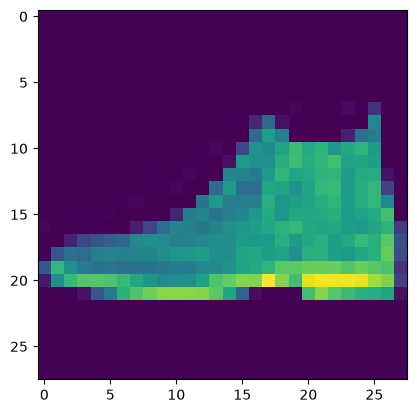

In [13]:
test_image(vanilla_jax_endpoint, x_test, y_test, 0)

True Label: 9
Predicted Label: 9


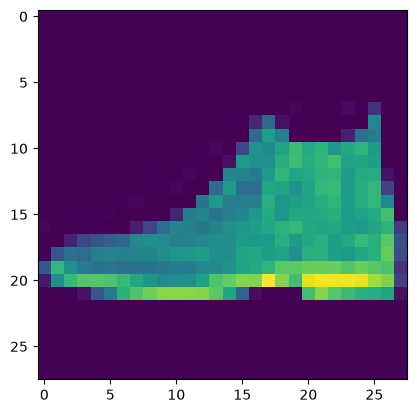

In [14]:
test_image(stax_endpoint, x_test, y_test, 0)

True Label: 9
Predicted Label: 7


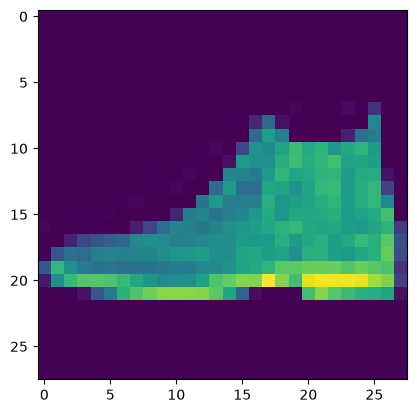

In [15]:
test_image(trax_endpoint, x_test, y_test, 0)

## Optional: Delete the running endpoints

In [16]:
# Clean-Up: delete endpoints, endpoint configs, and models
for endpoint, config_name, model_name in [
    (vanilla_jax_endpoint, vanilla_jax_config_name, vanilla_jax_model_name),
    (stax_endpoint, stax_config_name, stax_model_name),
    (trax_endpoint, trax_config_name, trax_model_name),
]:
    endpoint.delete()
    EndpointConfig.get(config_name).delete()
    Model.get(model_name).delete()

[07/13/26 12:31:26] INFO     Deleting Endpoint - jax-2026-07-13-19-23-13                         ]8;id=3623946;file:///Users/lucasjia/pysdk/pysdk-workspace/sagemaker-python-sdk-lucas/sagemaker-core/src/sagemaker/core/resources.py\resources.py]8;;\:]8;id=3623947;file:///Users/lucasjia/pysdk/pysdk-workspace/sagemaker-python-sdk-lucas/sagemaker-core/src/sagemaker/core/resources.py#10428\10428]8;;\

                    INFO     Deleting EndpointConfig - jax-2026-07-13-19-23-13-config            ]8;id=3623953;file:///Users/lucasjia/pysdk/pysdk-workspace/sagemaker-python-sdk-lucas/sagemaker-core/src/sagemaker/core/resources.py\resources.py]8;;\:]8;id=3623954;file:///Users/lucasjia/pysdk/pysdk-workspace/sagemaker-python-sdk-lucas/sagemaker-core/src/sagemaker/core/resources.py#11220\11220]8;;\

[07/13/26 12:31:27] INFO     Deleting Model - jax-2026-07-13-19-23-13-model                      ]8;id=3623960;file:///Users/lucasjia/pysdk/pysdk-workspace/sagemaker-python-sdk-lucas/sagemaker-core/src/sagemaker/core/resources.py\resources.py]8;;\:]8;id=3623961;file:///Users/lucasjia/pysdk/pysdk-workspace/sagemaker-python-sdk-lucas/sagemaker-core/src/sagemaker/core/resources.py#20624\20624]8;;\

                    INFO     Deleting Endpoint - stax-2026-07-13-19-28-31                        ]8;id=3623966;file:///Users/lucasjia/pysdk/pysdk-workspace/sagemaker-python-sdk-lucas/sagemaker-core/src/sagemaker/core/resources.py\resources.py]8;;\:]8;id=3623967;file:///Users/lucasjia/pysdk/pysdk-workspace/sagemaker-python-sdk-lucas/sagemaker-core/src/sagemaker/core/resources.py#10428\10428]8;;\

                    INFO     Deleting EndpointConfig - stax-2026-07-13-19-28-31-config           ]8;id=3623972;file:///Users/lucasjia/pysdk/pysdk-workspace/sagemaker-python-sdk-lucas/sagemaker-core/src/sagemaker/core/resources.py\resources.py]8;;\:]8;id=3623973;file:///Users/lucasjia/pysdk/pysdk-workspace/sagemaker-python-sdk-lucas/sagemaker-core/src/sagemaker/core/resources.py#11220\11220]8;;\

[07/13/26 12:31:28] INFO     Deleting Model - stax-2026-07-13-19-28-31-model                     ]8;id=3623978;file:///Users/lucasjia/pysdk/pysdk-workspace/sagemaker-python-sdk-lucas/sagemaker-core/src/sagemaker/core/resources.py\resources.py]8;;\:]8;id=3623979;file:///Users/lucasjia/pysdk/pysdk-workspace/sagemaker-python-sdk-lucas/sagemaker-core/src/sagemaker/core/resources.py#20624\20624]8;;\

                    INFO     Deleting Endpoint - trax-2026-07-13-19-25-57                        ]8;id=3623984;file:///Users/lucasjia/pysdk/pysdk-workspace/sagemaker-python-sdk-lucas/sagemaker-core/src/sagemaker/core/resources.py\resources.py]8;;\:]8;id=3623985;file:///Users/lucasjia/pysdk/pysdk-workspace/sagemaker-python-sdk-lucas/sagemaker-core/src/sagemaker/core/resources.py#10428\10428]8;;\

[07/13/26 12:31:29] INFO     Deleting EndpointConfig - trax-2026-07-13-19-25-57-config           ]8;id=3623990;file:///Users/lucasjia/pysdk/pysdk-workspace/sagemaker-python-sdk-lucas/sagemaker-core/src/sagemaker/core/resources.py\resources.py]8;;\:]8;id=3623991;file:///Users/lucasjia/pysdk/pysdk-workspace/sagemaker-python-sdk-lucas/sagemaker-core/src/sagemaker/core/resources.py#11220\11220]8;;\

                    INFO     Deleting Model - trax-2026-07-13-19-25-57-model                     ]8;id=3623996;file:///Users/lucasjia/pysdk/pysdk-workspace/sagemaker-python-sdk-lucas/sagemaker-core/src/sagemaker/core/resources.py\resources.py]8;;\:]8;id=3623997;file:///Users/lucasjia/pysdk/pysdk-workspace/sagemaker-python-sdk-lucas/sagemaker-core/src/sagemaker/core/resources.py#20624\20624]8;;\

## Notebook CI Test Results

This notebook was tested in multiple regions. The test results are as follows, except for us-west-2 which is shown at the top of the notebook.

![This us-east-1 badge failed to load. Check your device's internet connectivity, otherwise the service is currently unavailable](https://prod.us-west-2.tcx-beacon.docs.aws.dev/sagemaker-nb/us-east-1/build_and_train_models|sm-jax_bring_your_own|sm-jax_bring_your_own.ipynb)

![This us-east-2 badge failed to load. Check your device's internet connectivity, otherwise the service is currently unavailable](https://prod.us-west-2.tcx-beacon.docs.aws.dev/sagemaker-nb/us-east-2/build_and_train_models|sm-jax_bring_your_own|sm-jax_bring_your_own.ipynb)

![This us-west-1 badge failed to load. Check your device's internet connectivity, otherwise the service is currently unavailable](https://prod.us-west-2.tcx-beacon.docs.aws.dev/sagemaker-nb/us-west-1/build_and_train_models|sm-jax_bring_your_own|sm-jax_bring_your_own.ipynb)

![This ca-central-1 badge failed to load. Check your device's internet connectivity, otherwise the service is currently unavailable](https://prod.us-west-2.tcx-beacon.docs.aws.dev/sagemaker-nb/ca-central-1/build_and_train_models|sm-jax_bring_your_own|sm-jax_bring_your_own.ipynb)

![This sa-east-1 badge failed to load. Check your device's internet connectivity, otherwise the service is currently unavailable](https://prod.us-west-2.tcx-beacon.docs.aws.dev/sagemaker-nb/sa-east-1/build_and_train_models|sm-jax_bring_your_own|sm-jax_bring_your_own.ipynb)

![This eu-west-1 badge failed to load. Check your device's internet connectivity, otherwise the service is currently unavailable](https://prod.us-west-2.tcx-beacon.docs.aws.dev/sagemaker-nb/eu-west-1/build_and_train_models|sm-jax_bring_your_own|sm-jax_bring_your_own.ipynb)
